In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\msambare\fer2013\versions\1


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/train",
    image_size=(48,48),
    color_mode="grayscale",
    batch_size=64
)


Found 28709 files belonging to 7 classes.


In [4]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/test",
    image_size=(48,48),
    color_mode="grayscale",
    batch_size=64
)


Found 7178 files belonging to 7 classes.


In [ ]:
## Print class names
class_names = train_ds.class_names
print(class_names)



['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels[:10])


(64, 48, 48, 1)
tf.Tensor([0 6 2 6 2 2 3 3 6 5], shape=(10,), dtype=int32)


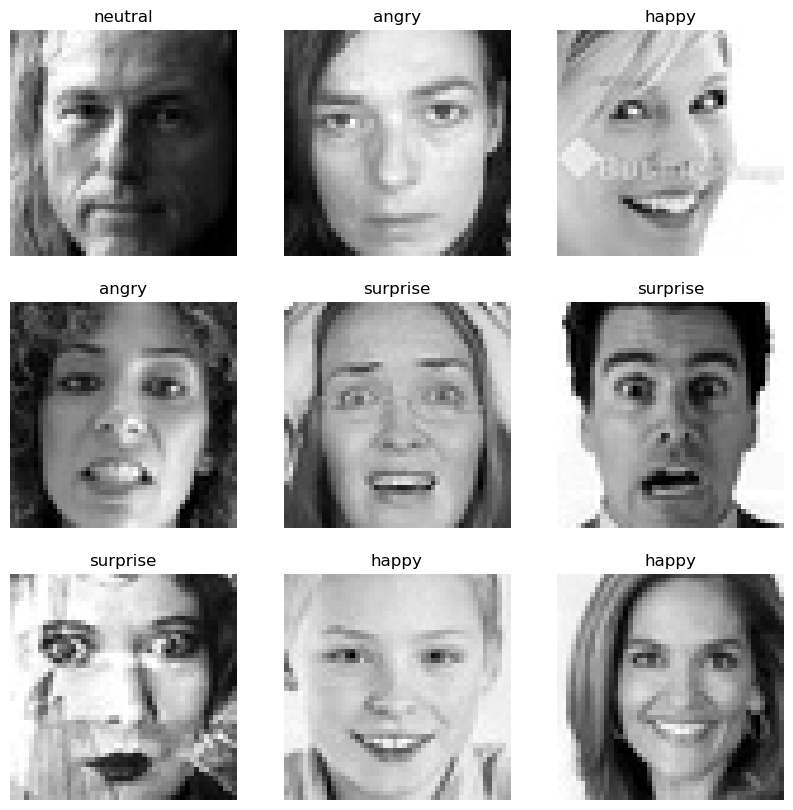

In [7]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap="gray")
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [8]:
##normalize pixel values
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


In [9]:
#Optimize Dataset Pipeline
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])


In [12]:
from tensorflow.keras import regularizers
from tensorflow.keras import layers

model = tf.keras.Sequential([

    data_augmentation,

    # -------- Block 1 --------
    layers.Conv2D(64, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(0.0001),
                  input_shape=(48,48,1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(64, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),

    # -------- Block 2 --------
    layers.Conv2D(128, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(128, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),

    # -------- Block 3 --------
    layers.Conv2D(256, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(256, (3,3), padding='same',
                  kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),

    # -------- Head --------
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.0001)),
    layers.Dropout(0.4),

    layers.Dense(7, activation='softmax')
])


c:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)


In [15]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=test_ds,
    callbacks=[early_stop]
)


Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 616s 1s/step - accuracy: 0.2718 - loss: 1.8683 - val_accuracy: 0.2314 - val_loss: 2.5623
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 335s 747ms/step - accuracy: 0.3816 - loss: 1.6578 - val_accuracy: 0.3930 - val_loss: 1.5866
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 327s 729ms/step - accuracy: 0.4568 - loss: 1.5119 - val_accuracy: 0.4423 - val_loss: 1.5734
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 330s 735ms/step - accuracy: 0.4959 - loss: 1.4211 - val_accuracy: 0.2707 - val_loss: 2.0721
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 430s 957ms/step - accuracy: 0.5178 - loss: 1.3621 - val_accuracy: 0.4904 - val_loss: 1.4215
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 732s 2s/step - accuracy: 0.5343 - loss: 1.3190 - val_accuracy: 0.4149 - val_loss: 1.5223
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 386s 858ms/step - accuracy: 0.5455 - loss: 1.2853 - val_accuracy: 0.4968 - val_loss: 1.4315
Epoch 8/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 331s 737ms/step - accuracy: 0.5585 - loss:

In [16]:
train_loss, train_acc = model.evaluate(train_ds)
val_loss, val_acc = model.evaluate(test_ds)

print("Final Training Accuracy:", train_acc)
print("Final Validation Accuracy:", val_acc)


449/449 ━━━━━━━━━━━━━━━━━━━━ 67s 150ms/step - accuracy: 0.6648 - loss: 0.9939
113/113 ━━━━━━━━━━━━━━━━━━━━ 17s 149ms/step - accuracy: 0.6213 - loss: 1.0888
Final Training Accuracy: 0.6648089289665222
Final Validation Accuracy: 0.6213430166244507


In [17]:
model.save("fer_emotion_model.h5")
